#Data Reading and Preprocessing

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler


 Read Dataset

In [ ]:
data = pd.read_csv('fake_news_dataset.csv')

 Basic Info

In [ ]:
data.head()

In [ ]:
data.describe()

Check for Missing Values

In [ ]:
data.isnull().sum()

In [ ]:
# prompt: Visualizes where missing data exists using bar plot.please maintain use colors

import matplotlib.pyplot as plt
import seaborn as sns
# Visualize missing data
missing_counts = data.isnull().sum()
missing_counts = missing_counts[missing_counts > 0].sort_values(ascending=False)
plt.figure(figsize=(10, 6))
sns.barplot(x=missing_counts.index, y=missing_counts.values, palette='viridis')
plt.title('Missing Data Count by Column')
plt.ylabel('Number of Missing Values')
plt.xlabel('Columns')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


Fill Missing Values

In [ ]:
# Fill missing categorical data with mode
data['source'] = data['source'].fillna(data['source'].mode()[0])
data['author'] = data['author'].fillna(data['author'].mode()[0])


In [ ]:
# prompt: plt.figure(figsize=(10, 6))
# sns.heatmap(data[cols_to_visualize].isnull(), cbar=False, cmap='viridis')
# plt.title('Missing Data Heatmap')
# plt.xlabel('Column Name')
# plt.ylabel('Row Index')
# plt.show() please add values in a heat map for every box give it in a grid format

# import matplotlib.pyplot as plt
# plt.figure(figsize=(12, 8))
# sns.heatmap(data[cols_to_visualize].isnull(), cbar=True, cmap='viridis', annot=True, fmt='d')
# plt.title('Missing Data Heatmap with Counts')
# plt.xlabel('Column Name')
# plt.ylabel('Row Index')
# plt.show()

Drop Unnecessary Columns

In [ ]:
data = data.drop(['date', 'title','text'], axis=1)

Encode Categorical Variables

In [ ]:
le = LabelEncoder()

data['label'] = le.fit_transform(data['label'])          # fake=0, real=1
data['source'] = le.fit_transform(data['source'])
data['author'] = le.fit_transform(data['author'])
data['category'] = le.fit_transform(data['category'])


Feature and Target Split

In [ ]:
x = data.drop('label', axis=1)
y = data['label']


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Count the occurrences of each class in the 'label' column
label_counts = y.value_counts()

# Map the numerical labels back to their original string values for better interpretation
label_map = {0: 'Fake', 1: 'Real'}
label_counts.index = label_counts.index.map(label_map)

# Create the bar plot
plt.figure(figsize=(6, 4))
ax = sns.barplot(x=label_counts.index, y=label_counts.values, palette=['red', 'green'])

# Add the count of values on top of the bars
for p in ax.patches:
    ax.annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points')

plt.title('Distribution of Real vs. Fake News')
plt.xlabel('Label')
plt.ylabel('Count')
plt.show()

 Train-Test Split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)


 Feature Scaling

In [ ]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

#Training

In [ ]:
from sklearn.linear_model import Perceptron, LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [ ]:
per = Perceptron()
LR = LogisticRegression()
svm=SVC()
knn=KNeighborsClassifier(n_neighbors=8)
dt = DecisionTreeClassifier()
rf = RandomForestClassifier()
record={}

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

In [ ]:
def print_metrics(model,y_true, y_pred, y_proba):
    print(f"Metrics for {model} :")
    print("---------------------------------")
    print(f"Accuracy       : {accuracy_score(y_true.astype(int), y_pred.astype(int)):.4f}")
    print(f"Precision      : {precision_score(y_true.astype(int), y_pred.astype(int)):.4f}")
    print(f"Recall         : {recall_score(y_true.astype(int), y_pred.astype(int)):.4f}")
    print(f"F1 Score       : {f1_score(y_true.astype(int), y_pred.astype(int)):.4f}")

def plot_confusion_matrix_heatmap(model, y_true, y_pred, labels=None):
    y_true = y_true.astype(int)
    y_pred = y_pred.astype(int)
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 4))

    if labels is None:
        labels = np.unique(y_true)

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title(f'Confusion Matrix Heatmap of {model}')
    plt.show()


In [ ]:
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

**Perceptron**

In [ ]:
y_train = y_train.astype(int)
per = Perceptron()
per.fit(X_train, y_train)
y_pred = per.predict(X_test)
y_proba = per.decision_function(X_test)
model='perceptron'
record[model]=accuracy_score(y_test.astype(int), y_pred)

In [ ]:
print_metrics(model, y_test, y_pred, y_proba)

In [ ]:
plot_confusion_matrix_heatmap(model,y_test, y_pred, labels=None)

In [ ]:
print(classification_report(y_test.astype(int), y_pred))

**Logistic Regression**

In [ ]:
LR = LogisticRegression()
LR.fit(X_train, y_train)
y_pred = LR.predict(X_test)
y_proba = LR.predict_proba(X_test)[:, 1]
model = 'logistic_regression'
record[model] = accuracy_score(y_test.astype(int), y_pred.astype(int))
print_metrics(model, y_test, y_pred, y_proba)

In [ ]:
plot_confusion_matrix_heatmap(model, y_test.astype(int), y_pred.astype(int))

In [ ]:
print(classification_report(y_test.astype(int), y_pred.astype(int)))

**Support Vector Machine**

In [ ]:
# from sklearn.svm import SVC

# svm = SVC(probability=True)
# svm.fit(X_train, y_train)
# y_pred = svm.predict(X_test)
# y_proba = svm.predict_proba(X_test)[:, 1]
# model = 'svm'
# # Convert y_test and y_pred to integer type before calculating accuracy
# record[model] = accuracy_score(y_test.astype(int), y_pred.astype(int))

# y_pred_int = y_pred.astype(int)
# y_test_int = y_test.astype(int)

In [ ]:
#print_metrics(model, y_test_int, y_pred_int, y_proba)

In [ ]:
#plot_confusion_matrix_heatmap(model, y_test_int, y_pred_int)

In [ ]:
#print(classification_report(y_test_int, y_pred_int))

**K- Nearest Neighbour**

In [ ]:
# KNN
knn = KNeighborsClassifier(n_neighbors=8)
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)
y_proba = knn.predict_proba(X_test)[:, 1]
model = 'knn'
record[model] = accuracy_score(y_test.astype(int), y_pred.astype(int))

In [ ]:
print_metrics(model, y_test.astype(int), y_pred.astype(int), y_proba)

Metrics for knn :
---------------------------------
Accuracy       : 0.5030
Precision      : 0.4941
Recall         : 0.3638
F1 Score       : 0.4191


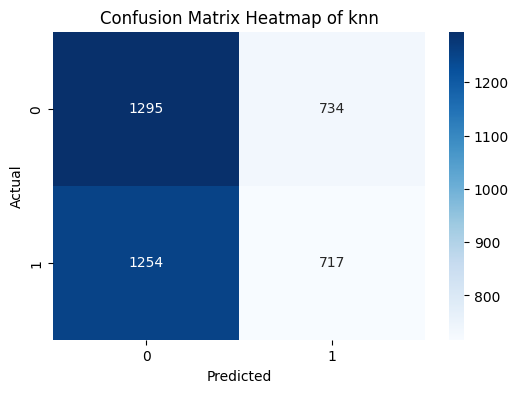

In [ ]:
plot_confusion_matrix_heatmap(model, y_test.astype(int), y_pred.astype(int))

In [ ]:
print(classification_report(y_test.astype(int), y_pred.astype(int)))

Decision Tree

In [ ]:
dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)
y_pred = dt.predict(X_test)
y_proba = dt.predict_proba(X_test)[:, 1]
model = 'decision_tree'
record[model] = accuracy_score(y_test.astype(int), y_pred.astype(int))

In [ ]:
print_metrics(model, y_test.astype(int), y_pred.astype(int), y_proba)

Metrics for decision_tree :
---------------------------------
Accuracy       : 0.5048
Precision      : 0.4974
Recall         : 0.4911
F1 Score       : 0.4943


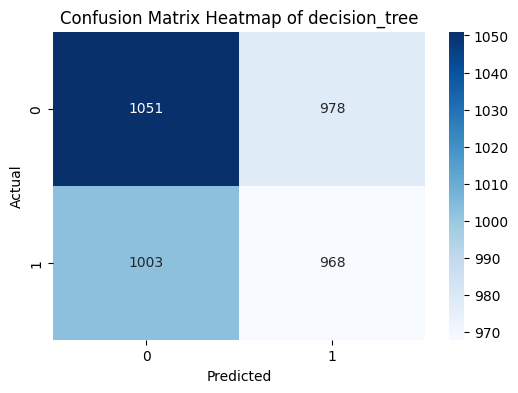

In [ ]:
plot_confusion_matrix_heatmap(model, y_test.astype(int), y_pred.astype(int))

In [ ]:
print(classification_report(y_test.astype(int), y_pred.astype(int)))

              precision    recall  f1-score   support

           0       0.51      0.52      0.51      2029
           1       0.50      0.49      0.49      1971

    accuracy                           0.50      4000
   macro avg       0.50      0.50      0.50      4000
weighted avg       0.50      0.50      0.50      4000



**Random Forest**

In [ ]:
rf = RandomForestClassifier()
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)
y_proba = rf.predict_proba(X_test)[:, 1]
model = 'random_forest'
record[model] = accuracy_score(y_test.astype(int), y_pred.astype(int))

In [ ]:
print_metrics(model, y_test.astype(int), y_pred.astype(int), y_proba)

Metrics for random_forest :
---------------------------------
Accuracy       : 0.5005
Precision      : 0.4931
Recall         : 0.4876
F1 Score       : 0.4903


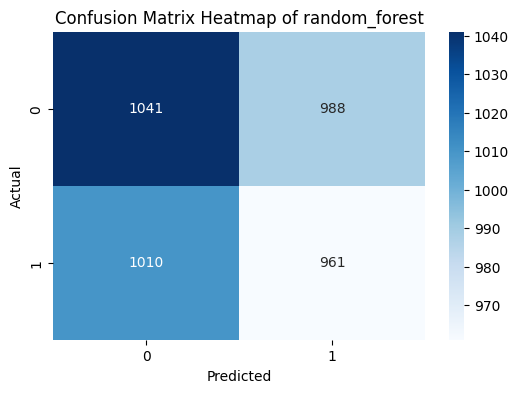

In [ ]:
plot_confusion_matrix_heatmap(model, y_test.astype(int), y_pred.astype(int))

In [ ]:
print(classification_report(y_test.astype(int), y_pred.astype(int)))

              precision    recall  f1-score   support

           0       0.51      0.51      0.51      2029
           1       0.49      0.49      0.49      1971

    accuracy                           0.50      4000
   macro avg       0.50      0.50      0.50      4000
weighted avg       0.50      0.50      0.50      4000



In [ ]:
# prompt: please give the best model depending on accuracy ,precision, recall, confusion matrix

# Evaluate models and store metrics
model_metrics = {}

# Perceptron
per_y_pred = per.predict(X_test).astype(int)
model_metrics['Perceptron'] = {
    'Accuracy': accuracy_score(y_test.astype(int), per_y_pred),
    'Precision': precision_score(y_test.astype(int), per_y_pred),
    'Recall': recall_score(y_test.astype(int), per_y_pred),
    'F1 Score': f1_score(y_test.astype(int), per_y_pred),
    'Confusion Matrix': confusion_matrix(y_test.astype(int), per_y_pred)
}

# Logistic Regression
lr_y_pred = LR.predict(X_test).astype(int)
model_metrics['Logistic Regression'] = {
    'Accuracy': accuracy_score(y_test.astype(int), lr_y_pred),
    'Precision': precision_score(y_test.astype(int), lr_y_pred),
    'Recall': recall_score(y_test.astype(int), lr_y_pred),
    'F1 Score': f1_score(y_test.astype(int), lr_y_pred),
    'Confusion Matrix': confusion_matrix(y_test.astype(int), lr_y_pred)
}

# KNN
knn_y_pred = knn.predict(X_test).astype(int)
model_metrics['K-Nearest Neighbour'] = {
    'Accuracy': accuracy_score(y_test.astype(int), knn_y_pred),
    'Precision': precision_score(y_test.astype(int), knn_y_pred),
    'Recall': recall_score(y_test.astype(int), knn_y_pred),
    'F1 Score': f1_score(y_test.astype(int), knn_y_pred),
    'Confusion Matrix': confusion_matrix(y_test.astype(int), knn_y_pred)
}

# Decision Tree
dt_y_pred = dt.predict(X_test).astype(int)
model_metrics['Decision Tree'] = {
    'Accuracy': accuracy_score(y_test.astype(int), dt_y_pred),
    'Precision': precision_score(y_test.astype(int), dt_y_pred),
    'Recall': recall_score(y_test.astype(int), dt_y_pred),
    'F1 Score': f1_score(y_test.astype(int), dt_y_pred),
    'Confusion Matrix': confusion_matrix(y_test.astype(int), dt_y_pred)
}

# Random Forest
rf_y_pred = rf.predict(X_test).astype(int)
model_metrics['Random Forest'] = {
    'Accuracy': accuracy_score(y_test.astype(int), rf_y_pred),
    'Precision': precision_score(y_test.astype(int), rf_y_pred),
    'Recall': recall_score(y_test.astype(int), rf_y_pred),
    'F1 Score': f1_score(y_test.astype(int), rf_y_pred),
    'Confusion Matrix': confusion_matrix(y_test.astype(int), rf_y_pred)
}

# Display metrics for comparison
print("Model Performance Comparison:")
print("-" * 30)
for model_name, metrics in model_metrics.items():
    print(f"\n{model_name}:")
    print(f"  Accuracy: {metrics['Accuracy']:.4f}")
    print(f"  Precision: {metrics['Precision']:.4f}")
    print(f"  Recall: {metrics['Recall']:.4f}")
    print(f"  F1 Score: {metrics['F1 Score']:.4f}")
    # You can choose to print confusion matrix here if desired, but it might be verbose
    # print("  Confusion Matrix:\n", metrics['Confusion Matrix'])

# Determine the best model based on a primary metric (e.g., F1-score)
best_model_name = None
best_f1_score = -1

print("\nDetermining the Best Model (based on F1 Score):")
print("-" * 40)

for model_name, metrics in model_metrics.items():
    if metrics['F1 Score'] > best_f1_score:
        best_f1_score = metrics['F1 Score']
        best_model_name = model_name

print(f"The best model is: {best_model_name} with an F1 Score of {best_f1_score:.4f}")

# You might want to consider other factors or choose a different primary metric depending on the problem
# For example, if minimizing False Negatives is critical, you might prioritize Recall.

# To get the specific metrics of the best model:
if best_model_name:
    print("\nMetrics of the Best Model:")
    print("-" * 30)
    print(f"Model: {best_model_name}")
    print(f"Accuracy: {model_metrics[best_model_name]['Accuracy']:.4f}")
    print(f"Precision: {model_metrics[best_model_name]['Precision']:.4f}")
    print(f"Recall: {model_metrics[best_model_name]['Recall']:.4f}")
    print(f"F1 Score: {model_metrics[best_model_name]['F1 Score']:.4f}")
    print("Confusion Matrix:\n", model_metrics[best_model_name]['Confusion Matrix'])

    # Display confusion matrix heatmap for the best model
    print(f"\nConfusion Matrix for the Best Model ({best_model_name}):")
    plot_confusion_matrix_heatmap(best_model_name, y_test, model_metrics[best_model_name]['Confusion Matrix'], labels=['Fake', 'Real'])

Model Performance Comparison:
------------------------------

Perceptron:
  Accuracy: 0.4803
  Precision: 0.4590
  Recall: 0.3070
  F1 Score: 0.3679

Logistic Regression:
  Accuracy: 0.4885
  Precision: 0.4783
  Recall: 0.4196
  F1 Score: 0.4470

K-Nearest Neighbour:
  Accuracy: 0.5030
  Precision: 0.4941
  Recall: 0.3638
  F1 Score: 0.4191

Decision Tree:
  Accuracy: 0.5048
  Precision: 0.4974
  Recall: 0.4911
  F1 Score: 0.4943

Random Forest:
  Accuracy: 0.5005
  Precision: 0.4931
  Recall: 0.4876
  F1 Score: 0.4903

Determining the Best Model (based on F1 Score):
----------------------------------------
The best model is: Decision Tree with an F1 Score of 0.4943

Metrics of the Best Model:
------------------------------
Model: Decision Tree
Accuracy: 0.5048
Precision: 0.4974
Recall: 0.4911
F1 Score: 0.4943
Confusion Matrix:
 [[1051  978]
 [1003  968]]

Confusion Matrix for the Best Model (Decision Tree):


TypeError: plot_confusion_matrix_heatmap() missing 1 required positional argument: 'y_pred'